In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
# df= pd.read_csv(r"C:\Users\Chinmay Pratap Dalvi\Downloads\Boston-house-price-data.csv")

In [3]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Chinmay Pratap Dalvi\AppData\Local\Temp\ipykernel_16076\16828617.py:2: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [4]:

df_boston = pd.DataFrame(data, columns=['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'])
df_boston['PRICE'] = target

In [5]:
df_boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


In [6]:
# Variables in order:
#  CRIM     per capita crime rate by town
#  ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
#  INDUS    proportion of non-retail business acres per town
#  CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
#  NOX      nitric oxides concentration (parts per 10 million)
#  RM       average number of rooms per dwelling
#  AGE      proportion of owner-occupied units built prior to 1940
#  DIS      weighted distances to five Boston employment centres
#  RAD      index of accessibility to radial highways
#  TAX      full-value property-tax rate per $10,000
#  PTRATIO  pupil-teacher ratio by town
#  B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
#  LSTAT    % lower status of the population
#  MEDV     Median value of owner-occupied homes in $1000's

In [7]:
df_boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [8]:
df_boston.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

In [9]:
df_boston.shape

(506, 14)

In [10]:
x=df_boston.drop('PRICE', axis=1)     #multiple linear regression method 1

In [11]:
x= df_boston.iloc[:,:-1]          #method 2

In [12]:
y=df_boston['PRICE']
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: PRICE, Length: 506, dtype: float64

In [13]:
#model building

In [14]:
xc=sm.add_constant(x)
ols_model=sm.OLS(y,xc).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  PRICE   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          6.72e-135
Time:                        18:27:13   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4595      5.103      7.144      0.000      26.432      46.487
CRIM          -0.1080      0.033     -3.287      0.001      -0.173      -0.043
ZN             0.0464      0.014      3.382      0.001       0.019       0.073
INDUS          0.0206      0.061      0.334      0.738      -0.100       0.141
CHAS           2.6867      0.862      3.118      0.002       0.994       4.380
NOX          -17.7666      3.820     -4.651      0.000     -25.272     -10.262
RM             3.8099      0.418      9.116      0.000       2.989       4.631
AGE            0.0007      0.013      0.052      0.958      -0.025       0.027
DIS           -1.4756      0.199     -7.398      0.000      -1.867      -1.084
RAD            0.3060      0.066      4.613      0.000       0.176       0.436
TAX           -0.0123      0.004     -3.280      0.001      -0.020      -0.005
PTRATIO       -0.9527      0.131     -7.283      0.000      -1.210      -0.696
B              0.0093      0.003      3.467      0.001       0.004       0.015
LSTAT         -0.5248      0.051    -10.347      0.000      -0.624      -0.425
==============================================================================
Omnibus:                      178.041   Durbin-Watson:                   1.078
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              783.126
Skew:                           1.521   Prob(JB):                    8.84e-171
Kurtosis:                       8.281   Cond. No.                     1.51e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.51e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [15]:
y_pred=ols_model.fittedvalues
residuals=ols_model.resid
y_pred

0      30.003843
1      25.025562
2      30.567597
3      28.607036
4      27.943524
         ...    
501    23.533341
502    22.375719
503    27.627426
504    26.127967
505    22.344212
Length: 506, dtype: float64

In [16]:
#assumption 1: no multicollinearity

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

In [21]:
xc.columns

Index(['const', 'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
       'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'],
      dtype='object')

In [22]:
VIF(xc.values,1)

1.7921915474332406

In [23]:
VIF(xc.values,2)

2.298758178749441

In [27]:
vif_values = [VIF(xc.values, i) for i in range(xc.shape[1])]

DF1 = pd.DataFrame(vif_values, columns=['VIF Value'], index=xc.columns)
DF1 = DF1.sort_values('VIF Value', ascending=False)


In [28]:
DF1

,VIF Value
const,585.265238
TAX,9.008554
RAD,7.484496
NOX,4.393720
INDUS,3.991596
DIS,3.955945
AGE,3.100826
LSTAT,2.941491
ZN,2.298758
RM,1.933744


In [29]:
x=df_boston.drop(['TAX'],axis=1)
xc=sm.add_constant(x)

In [30]:
xc

,const,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,PTRATIO,B,LSTAT,PRICE
0,1.0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,15.3,396.90,4.98,24.0
1,1.0,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,17.8,396.90,9.14,21.6
2,1.0,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,17.8,392.83,4.03,34.7
3,1.0,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,18.7,394.63,2.94,33.4
4,1.0,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,1.0,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,21.0,391.99,9.67,22.4
502,1.0,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,21.0,396.90,9.08,20.6
503,1.0,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,21.0,396.90,5.64,23.9
504,1.0,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,21.0,393.45,6.48,22.0


In [31]:
vif_values=[ VIF(xc.values,i) for i in range(xc.shape[1])]
DF1=pd.DataFrame(vif_values,columns=['VIF Values'],index=xc.columns).sort_values('VIF Values', ascending= False)

In [32]:
DF1

,VIF Values
const,631.860301
NOX,4.578751
DIS,4.392557
PRICE,3.773177
LSTAT,3.561127
INDUS,3.235660
AGE,3.098057
RAD,2.898743
RM,2.260029
ZN,2.216337


In [33]:
#model building

In [35]:
import statsmodels.api as sm

ols_model = sm.OLS(y, xc).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.036e+31
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:52:36   Log-Likelihood:                 15309.
No. Observations:                 506   AIC:                        -3.059e+04
Df Residuals:                     492   BIC:                        -3.053e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.066e-14   1.99e-14     -0.536      0.5

In [37]:
y_pred=ols_model.fittedvalues
residuals= ols_model.resid

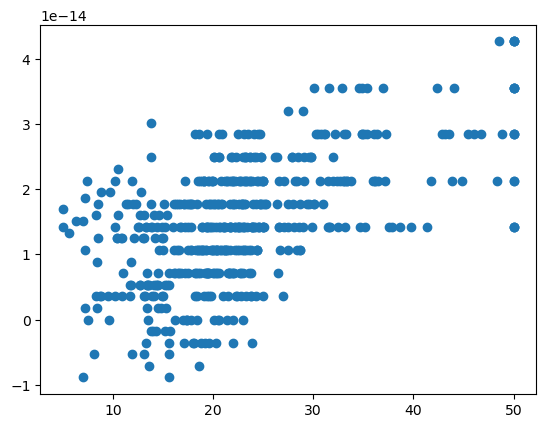

In [38]:
plt.scatter(y_pred, residuals)

In [39]:
#linear relationship btn dpendent and independent variable

In [40]:
#to test linearity
from statsmodels.stats.api import linear_rainbow
test_stat,p_value=linear_rainbow(ols_model)

In [41]:
test_stat,p_value

(-0.7454101385907238, 1.0)

In [42]:
#after model building tests

In [43]:
#2. independence of observations should exist(i.e Absence of auto-correlation)

In [45]:
from statsmodels.stats.stattools import durbin_watson

In [46]:
durbin_watson(residuals)

0.11472052986829133

In [47]:
# # 1. limits are "O to 2" positive autocorrelation
# # 2. limits are equal to 2 No autocorrelation
# # 3. limits are equal to 2 to 4 Negative correlation

# # positive autocorrelation --- because of exisiting residuals increasing
# positive autocorrelation

# because of exisiting residuals increasing

# negative autocorrelation because of exisiting residuals decreasing

In [48]:
# Assumption 4: HOMOSCEDASTICITY (NO HETEROSCEDASTICITY)

In [49]:
#variance among residuals equal

In [57]:
from statsmodels.stats.api import het_breuschpagan

In [58]:
het_breuschpagan(residuals, xc)[2:]

(364.1864469935931, 1.0768480348816198e-242)

In [50]:
#assumption 5 - normality test
# normality of residuals

In [51]:
import scipy.stats as stats

In [52]:
stats.shapiro(residuals)

ShapiroResult(statistic=0.9852462289363401, pvalue=5.24602462659681e-05)

In [53]:
from statsmodels.api import qqplot

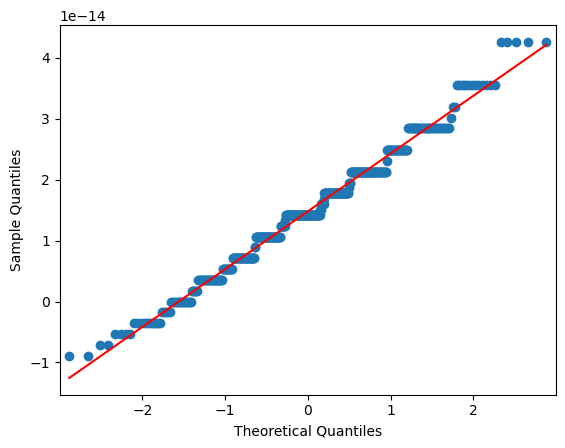

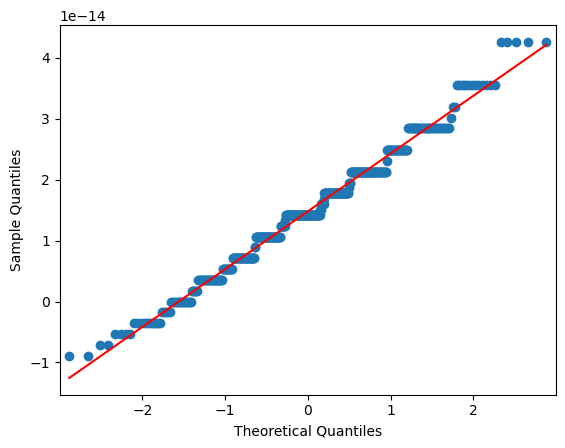

In [55]:
qqplot(residuals,line='r')

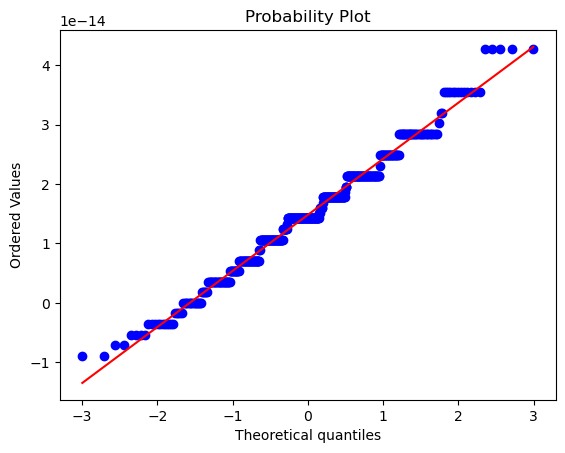

In [59]:
stats.probplot(residuals, plot=plt)
plt.show()

In [63]:
num = int(input("Enter number: "))

count = 0

for i in range(1, num + 1):
    if num % i == 0:
        count += 1

if count == 2:
    print("Prime Number")
else:
    print("Not Prime Number")

Enter number:  10


Not Prime Number
